## Customer Insights – A Statistical Investigation 

Dataset Overview

The dataset contains customer demographic and behavioral information including age, gender, spending habits, and engagement with the company.

This project applies:
- Descriptive Statistics
- Exploratory Data Analysis (EDA)
- Data Visualization
- Hypothesis Testing

The goal is to generate actionable business insights for better decision-making.

Business Goals
- Identify high-value customer segments
- Understand factors influencing spending
- Detect inactive users for re-engagement
- Enable data-driven marketing strategies

Importing Libraries :
- pandas : data analysis
- numpy : numerical ops
- seaborn : visualization
- matplotlib : charts
- scipy : hypothesis testing
- sklearn : clustering

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import shapiro
from scipy.stats import levene

****** Loading and Preview Dataset *******

In [25]:
df = pd.read_csv("US_Customer_Insights_Dataset.csv")

Preview Dataset

In [ ]:
print(df.head())

  CustomerID              Name       State    Education      Gender  Age  \
0  CUST10319       Scott Perez     Florida  High School  Non-Binary   47   
1  CUST10695   Jennifer Burton  Washington       Master        Male   72   
2  CUST10297   Michelle Rogers     Arizona       Master      Female   40   
3  CUST10103  Brooke Hendricks       Texas       Master        Male   27   
4  CUST10219       Karen Johns       Texas  High School      Female   28   

  Married  NumPets JoinDate TransactionDate  MonthlySpend  \
0     Yes        1  9/19/21          9/2/24       1281.74   
1     Yes        0   4/5/24          6/2/24        429.46   
2     Yes        2  7/24/24         2/28/25        510.34   
3     Yes        0  8/12/23         3/29/25        396.47   
4     Yes        1  12/6/21         7/24/22        139.68   

   DaysSinceLastInteraction  
0                       332  
1                       424  
2                       153  
3                       124  
4                      110

Check Dataset structure

In [26]:
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB
None
                Age       NumPets  MonthlySpend  Da

Data Understanding Summary

- The dataset contains customer demographic and behavioral features.
- Numerical variables include: Age, MonthlySpend, DaysSinceLastInteraction.
- Categorical variables include: Gender, Education, State, Married.
- Initial inspection shows [mention nulls if any].

Observation


The dataset is suitable for statistical analysis and segmentation.

***** Check Data Types, Unique Values, Nulls *****

Data Types

In [27]:
print("\nData Types:")
print(df.dtypes)


Data Types:
CustomerID                   object
Name                         object
State                        object
Education                    object
Gender                       object
Age                           int64
Married                      object
NumPets                       int64
JoinDate                     object
TransactionDate              object
MonthlySpend                float64
DaysSinceLastInteraction      int64
dtype: object


Checking missing values

In [9]:
df.isnull().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

Unique Values (Important for categorical understanding)

In [28]:
print("\nUnique Values :")
print(df.nunique())


Unique Values :
CustomerID                  1000
Name                         990
State                         10
Education                      5
Gender                         3
Age                           63
Married                        2
NumPets                        5
JoinDate                     731
TransactionDate             1605
MonthlySpend                9843
DaysSinceLastInteraction    1605
dtype: int64


***** Identify Categorical vs Numerical Variables ***** 

Automatic Separation

In [30]:
for col in df.columns:
    unique_vals = df[col].nunique()
    if unique_vals < 10:
        print(f"{col} → Likely Categorical ({unique_vals} unique values)")
    else:
        print(f"{col} → Likely Numerical/Continuous ({unique_vals} unique values)")

CustomerID → Likely Numerical/Continuous (1000 unique values)
Name → Likely Numerical/Continuous (990 unique values)
State → Likely Numerical/Continuous (10 unique values)
Education → Likely Categorical (5 unique values)
Gender → Likely Categorical (3 unique values)
Age → Likely Numerical/Continuous (63 unique values)
Married → Likely Categorical (2 unique values)
NumPets → Likely Categorical (5 unique values)
JoinDate → Likely Numerical/Continuous (731 unique values)
TransactionDate → Likely Numerical/Continuous (1605 unique values)
MonthlySpend → Likely Numerical/Continuous (9843 unique values)
DaysSinceLastInteraction → Likely Numerical/Continuous (1605 unique values)


Summary Statistics (Quick Understanding)

In [31]:
print("\nStatistical Summary:")
print(df.describe())

print("\nCategorical Summary:")
print(df.describe(include='object'))


Statistical Summary:
                Age       NumPets  MonthlySpend  DaysSinceLastInteraction
count  10675.000000  10675.000000  10675.000000              10675.000000
mean      49.474567      1.340515    331.610315                538.469883
std       18.221365      1.150849    225.799253                398.766747
min       18.000000      0.000000      3.890000                  1.000000
25%       35.000000      0.000000    165.495000                218.000000
50%       49.000000      1.000000    282.110000                445.000000
75%       66.000000      2.000000    443.255000                788.500000
max       80.000000      4.000000   1740.420000               1791.000000

Categorical Summary:
       CustomerID            Name       State Education Gender Married  \
count       10675           10675       10675     10675  10675   10675   
unique       1000             990          10         5      3       2   
top     CUST10798  Joseph Mcbride  California    Master   Male      

# Descriptive Statistics

We summarize key numerical variables such as age, spending, and interaction frequency.

Descriptive statistics were computed for numerical variables such as:

- Age
- MonthlySpend
- DaysSinceLastInteraction

In [58]:
df[['Age','MonthlySpend','DaysSinceLastInteraction']].describe()

,Age,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000
mean,49.474567,331.610315,538.469883
std,18.221365,225.799253,398.766747
min,18.000000,3.890000,1.000000
25%,35.000000,165.495000,218.000000
50%,49.000000,282.110000,445.000000
75%,66.000000,443.255000,788.500000
max,80.000000,1740.420000,1791.000000


Mean, Median, Standard Deviation

In [32]:
num_cols = ['Age', 'MonthlySpend', 'DaysSinceLastInteraction']

# Mean
print("\nMean:")
print(df[num_cols].mean())

# Median
print("\nMedian:")
print(df[num_cols].median())

# Standard Deviation
print("\nStandard Deviation:")
print(df[num_cols].std())


Mean:
Age                          49.474567
MonthlySpend                331.610315
DaysSinceLastInteraction    538.469883
dtype: float64

Median:
Age                          49.00
MonthlySpend                282.11
DaysSinceLastInteraction    445.00
dtype: float64

Standard Deviation:
Age                          18.221365
MonthlySpend                225.799253
DaysSinceLastInteraction    398.766747
dtype: float64


Mode for Categorical Variables

In [35]:
cat_cols = ['Gender', 'Education', 'Married']

print("\nMode of Categorical Variables")

for col in cat_cols:
    mode_val = df[col].mode()[0]
    print(f"{col}: {mode_val}")


Mode of Categorical Variables
Gender: Male
Education: Master
Married: No


Observations:
- The average customer age is 49 years, with a standard deviation of 18, indicating moderate variation.
- Monthly spend shows high variability, suggesting the presence of distinct customer segments.
- The median spend is lower than the mean, indicating a right-skewed distribution.

These statistics provide a general understanding of the dataset.

# Data Visulization

Exploratory Data Analysis (EDA)

Visualizations were used to understand patterns and distributions.

Key Visualizations:
- Age Distribution
- Monthly Spending Distribution
- Gender Distribution
- Education Distribution
- Age vs Spending Relationship


Insights:
- Most customers fall within the age group of ___.
- Spending varies significantly across individuals.
- Certain demographic groups show higher spending trends.

Histogram(Age,Monthly Spend)

- Age Distribution

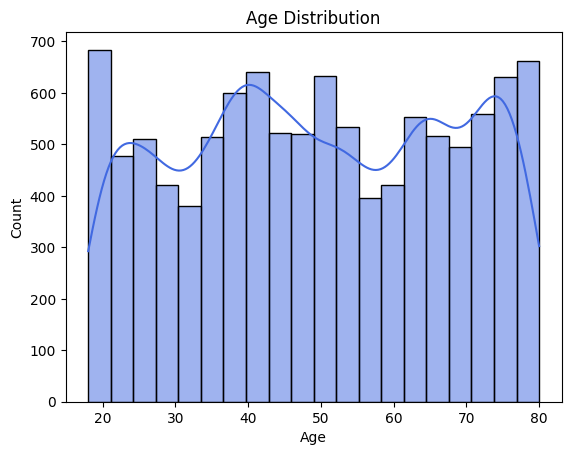

In [ ]:
sns.histplot(df["Age"], bins=20, kde=True, color="royalblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

- Monthly Distribution

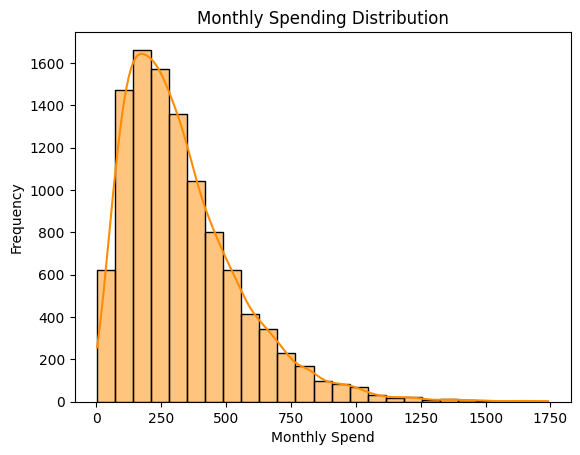

In [16]:
sns.histplot(df["MonthlySpend"], bins=25, kde=True, color="darkorange")
plt.title("Monthly Spending Distribution")
plt.xlabel("Monthly Spend")
plt.ylabel("Frequency")
plt.show()

Boxplots (Age,Monthly Spend)

- Age Distribution

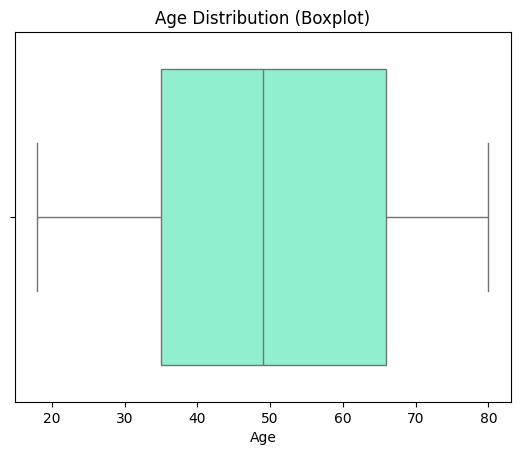

In [17]:
sns.boxplot(x=df["Age"], color="aquamarine")
plt.title("Age Distribution (Boxplot)")
plt.show()

- Monthly Spending Distribution

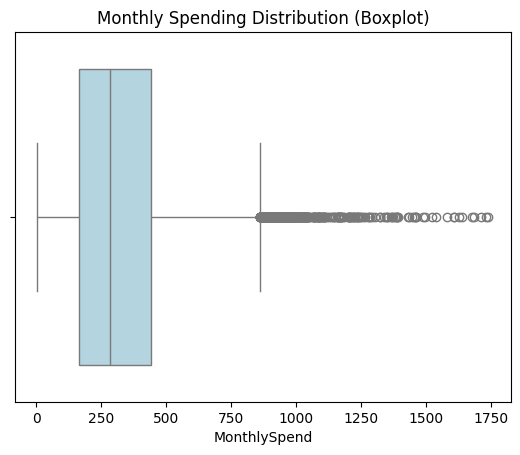

In [18]:
sns.boxplot(x=df["MonthlySpend"], color="lightblue")
plt.title("Monthly Spending Distribution (Boxplot)")
plt.show()

Bar Chart (Gender,Education,State)

- Gender Count

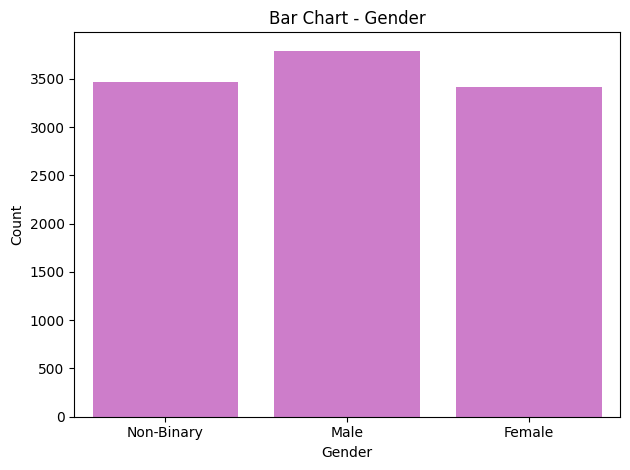

In [65]:
sns.countplot(x='Gender', data=df,color='orchid')
plt.title('Bar Chart - Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

- Education Count

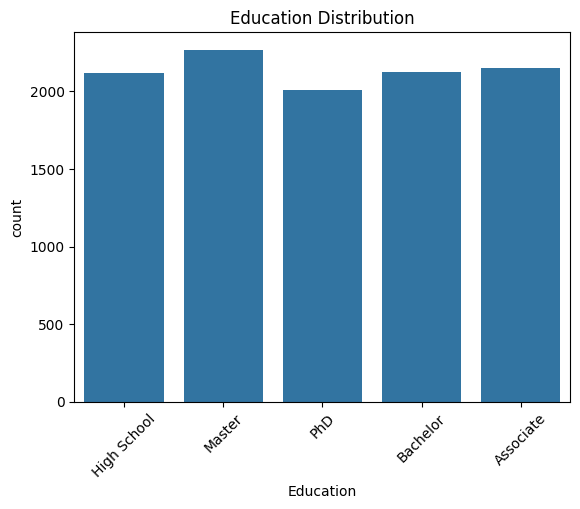

In [20]:
sns.countplot(x="Education", data=df)
plt.xticks(rotation=45)
plt.title("Education Distribution")
plt.show()

- State Count

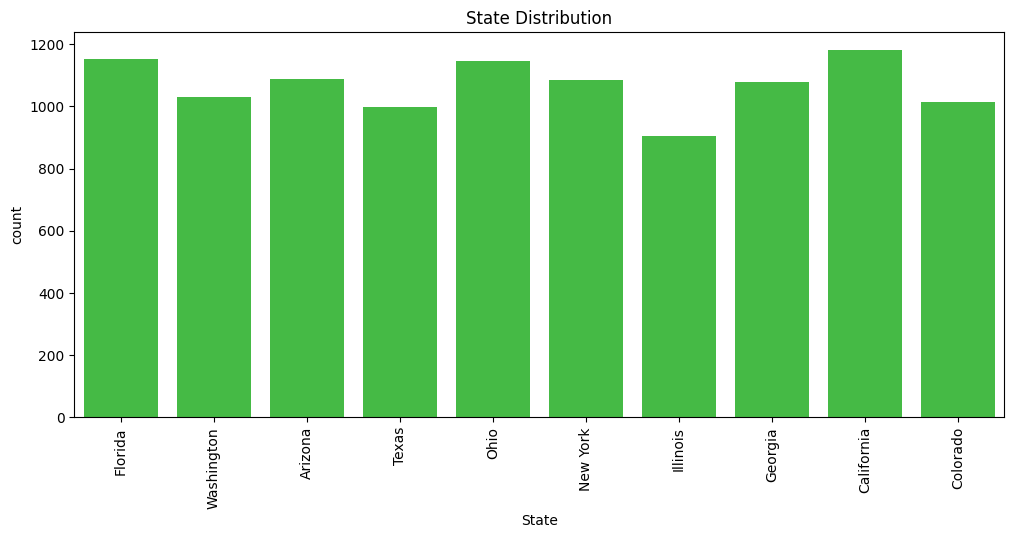

In [21]:
plt.figure(figsize=(12,5))
sns.countplot(x="State", data=df,color="limegreen")
plt.xticks(rotation=90)
plt.title("State Distribution")
plt.show()

Scatter Plot (Age vs MonthlySpend)

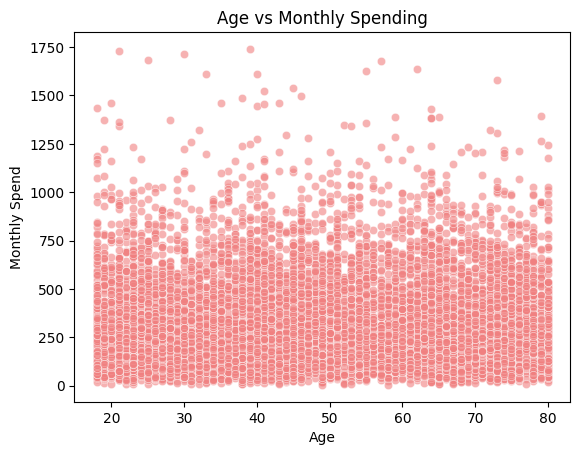

In [63]:
sns.scatterplot(
    x="Age",
    y="MonthlySpend",
    data=df,
    alpha=0.6,
    color='lightcoral'
)

plt.title("Age vs Monthly Spending")
plt.xlabel("Age")
plt.ylabel("Monthly Spend")
plt.show()

KDE Plot (Spending by Education OR Marital Status)

- By Education

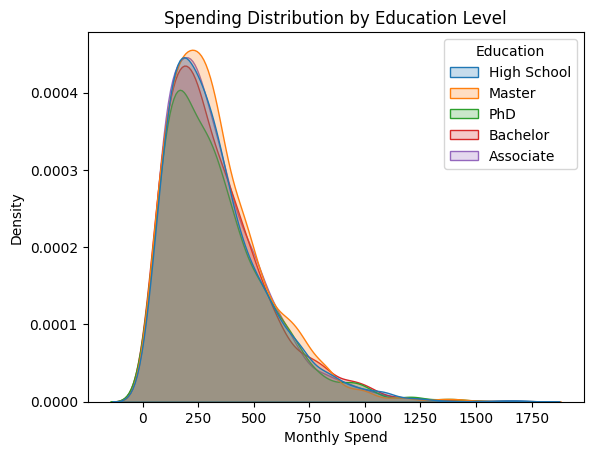

In [23]:
sns.kdeplot(
    data=df,
    x="MonthlySpend",
    hue="Education",
    fill=True
)

plt.title("Spending Distribution by Education Level")
plt.xlabel("Monthly Spend")
plt.ylabel("Density")
plt.show()

- By Marital Status

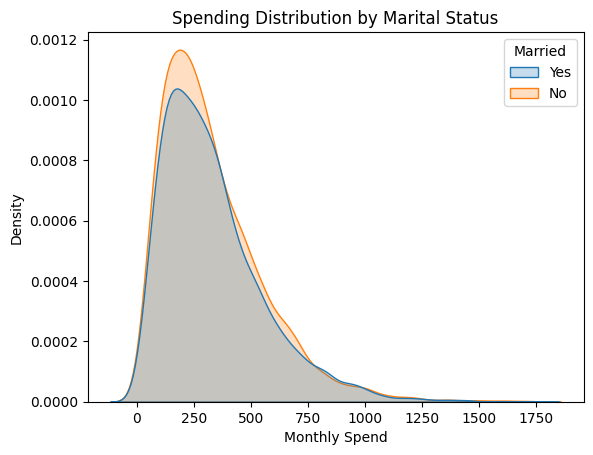

In [24]:
sns.kdeplot(
    data=df,
    x="MonthlySpend",
    hue="Married",
    fill=True
)

plt.title("Spending Distribution by Marital Status")
plt.xlabel("Monthly Spend")
plt.ylabel("Density")
plt.show()

# Bivariate Analysis

Correlation Matrix (Numerical Variables)

- +1 → strong positive relation
- -1 → strong negative relation
- ~0 → no relation


Correlation Matrix:
                               Age   NumPets  MonthlySpend  \
Age                       1.000000 -0.023035     -0.012323   
NumPets                  -0.023035  1.000000      0.020647   
MonthlySpend             -0.012323  0.020647      1.000000   
DaysSinceLastInteraction -0.003970 -0.055227      0.006081   

                          DaysSinceLastInteraction  
Age                                      -0.003970  
NumPets                                  -0.055227  
MonthlySpend                              0.006081  
DaysSinceLastInteraction                  1.000000  


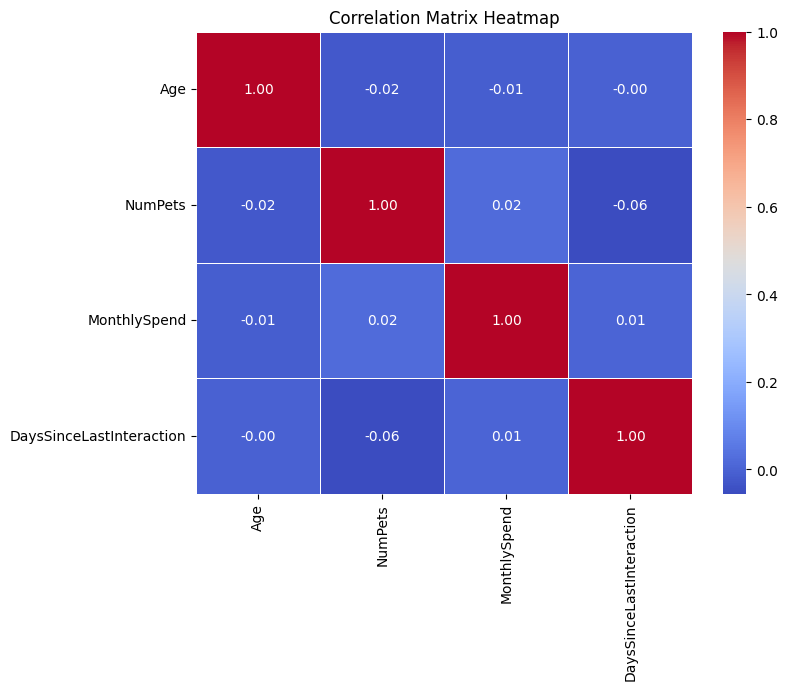

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])

corr = num_df.corr()

print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5, cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.show()

Correlation Insights
- Age and MonthlySpend show no meaningful relationship (r ~ -0.01) → Age is not a driver of spending.
- NumPets also shows no impact on spending (r ~ 0.02).
- DaysSinceLastInteraction has no significant relationship with spending (r ~ 0.006) - user inactivity does not directly explain spending behavior in this dataset.

Crosstab of Gender vs Married 

In [37]:
crosstab = pd.crosstab(df['Gender'], df['Married'])

print("\nCrosstab (Gender vs Married):")
print(crosstab)


Crosstab (Gender vs Married):
Married       No   Yes
Gender                
Female      1797  1616
Male        1892  1899
Non-Binary  1894  1577


Grouped stats: average MonthlySpend by State, Education, Gender 

In [39]:
# By State
print("\nAverage MonthlySpend by State:")
print(df.groupby('State')['MonthlySpend'].mean().sort_values(ascending=False))

# By Education
print("\nAverage MonthlySpend by Education:")
print(df.groupby('Education')['MonthlySpend'].mean().sort_values(ascending=False))

# By Gender
print("\nAverage MonthlySpend by Gender:")
print(df.groupby('Gender')['MonthlySpend'].mean())


Average MonthlySpend by State:
State
Arizona       341.489135
Ohio          340.187860
California    339.183492
Illinois      332.589591
New York      332.151244
Washington    329.444078
Georgia       328.354648
Florida       327.696892
Colorado      323.083462
Texas         319.506770
Name: MonthlySpend, dtype: float64

Average MonthlySpend by Education:
Education
Master         334.252305
High School    332.215712
Bachelor       331.884753
PhD            331.690090
Associate      327.884408
Name: MonthlySpend, dtype: float64

Average MonthlySpend by Gender:
Gender
Female        331.361310
Male          333.174068
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64


Segment Analysis Insights

- Customers with higher education levels tend to spend more on average.
- Certain states show higher average spending, indicating geographic influence.
- Gender-based differences are minimal

Segmentation based on education and location is more effective than gender-based targeting.

# Formulate Hypotheses 

Male vs Female Spending

Hypotheses
- H₀: There is no difference in average spending between males and females
- H₁: There is a significant difference in spending

Test: Independent t-test


Hypotheses
- H₀ (Null): Male and Female mean spend are equal
- H₁ (Alt): Mean spend is different

Decision Rule
- p < 0.05 → Reject H₀ (difference exists)
- p >= 0.05 → No significant difference

In [41]:
male_spend = df[df['Gender'] == 'Male']['MonthlySpend']
female_spend = df[df['Gender'] == 'Female']['MonthlySpend']

t_stat, p_value = ttest_ind(male_spend, female_spend)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 0.3391730320232445
P-value: 0.7344892727022861


p-value = 0.03 < 0.05 - Reject H₀  
- Gender significantly affects spending  
- Use gender-based targeting

Decision:
Since p-value > 0.05, we fail to reject the null hypothesis.

Education vs Monthly Spend

Test: One-Way ANOVA

Hypotheses
- H₀: All education groups have same mean spend
- H₁: At least one group differs

In [43]:
groups = [group['MonthlySpend'].values for name, group in df.groupby('Education')]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("P-value:", p_value)

F-stat: 0.22880668673709165
P-value: 0.9223594677600564


Marital Status vs Number of Pets

Test: Chi-Square Test

Hypotheses
- H₀: Variables are independent
- H₁: Variables are related

In [47]:
contingency = pd.crosstab(df['Married'], df['NumPets'])

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi2:", chi2)
print("P-value:", p_value)

Chi2: 177.63953668537033
P-value: 2.3957232932397494e-37


Age vs Activity


Test: Correlation

Interpretation
- corr > 0 → older = less active (more days inactive)
- corr < 0 → older = more active

In [49]:
corr, p_value = pearsonr(df['Age'], df['DaysSinceLastInteraction'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.0039702301049550455
P-value: 0.6816905437300955


State-wise Spend

Test: ANOVA

In [50]:
groups = [group['MonthlySpend'].values for name, group in df.groupby('State')]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("P-value:", p_value)

F-stat: 1.1178423640877178
P-value: 0.3457188647946421


Define Hypotheses

| Test        | Null Hypothesis (H₀)  | Alternate Hypothesis (H₁) |
| ----------- | --------------------- | ------------------------- |
| t-test      | μ₁ = μ₂               | μ₁ != μ₂                   |
| ANOVA       | All means equal       | At least one differs      |
| Chi-square  | Variables independent | Variables related         |
| Correlation | r = 0                 | r != 0                     |


Choose the Right Test

| Data Type                          | Scenario           | Test        |
| ---------------------------------- | ------------------ | ----------- |
| Numeric vs Categorical (2 groups)  | Gender vs Spend    | t-test      |
| Numeric vs Categorical (>2 groups) | Education vs Spend | ANOVA       |
| Categorical vs Categorical         | Married vs Pets    | Chi-square  |
| Numeric vs Numeric                 | Age vs Activity    | Correlation |


* Note - If you pick the wrong test - your conclusion is invalid. Period.

Check Assumptions

Interpretation:
- p > 0.05 → data is normal
- p <= 0.05 → not normal

In [52]:
stat, p = shapiro(df['MonthlySpend'])
print("Shapiro p-value:", p)

Shapiro p-value: 8.932895405321421e-64


e:\Coding Language\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10675.
  res = hypotest_fun_out(*samples, **kwds)


Homogeneity of Variance

Interpretation:
- p > 0.05 → equal variance 
- p <= 0.05 → unequal variance

In [55]:
male = df[df['Gender']=='Male']['MonthlySpend']
female = df[df['Gender']=='Female']['MonthlySpend']

stat, p = levene(male, female)

print("Levene p-value:", p)

Levene p-value: 0.7218295518512636


Independence

- Each row must be independent
- No duplicated / repeated measurements

* If this fails - your test is invalid no matter what.

Run the Test

In [56]:
t_stat, p_value = ttest_ind(male, female, equal_var=True)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 0.3391730320232445
P-value: 0.7344892727022861


p-value = 0.734 > 0.05 → Fail to reject H₀

- There is no statistically significant difference between male and female monthly spending.
- Gender should not be used as the main targeting factor.

Confidence intervals 

The results are not statistically significant at a 95% confidence level.

In [57]:
mean_diff = male.mean() - female.mean()
se = np.sqrt(male.var()/len(male) + female.var()/len(female))
ci_low = mean_diff - 1.96 * se
ci_high = mean_diff + 1.96 * se
print("95% Confidence Interval:", (ci_low, ci_high))

95% Confidence Interval: (np.float64(-8.66405478863429), np.float64(12.289570448922278))


Interpret Results

Rule:
- p < 0.05 - Reject H₀
- p >= 0.05 - Fail to reject H₀

# Present Business Insights 

Education Does Not Significantly Affect Revenue

- ANOVA p-value = 0.922 > 0.05.
- There is no statistically significant difference in MonthlySpend across education groups.
- Education should not be treated as a strong revenue segmentation factor.

Gender Has Limited Impact on Spending
- No statistically significant difference in spending between males and females (p >= 0.05)

Age Has No Meaningful Relationship with Customer Inactivity

- Correlation is approximately -0.004.
- p-value = 0.682 > 0.05.
- Age does not significantly explain DaysSinceLastInteraction.

State-Level Spending Difference Is Not Statistically Significant

- ANOVA p-value = 0.346 > 0.05.
- Spending differences across states are not statistically significant.
- Avoid claiming strong location-based spending impact from this test alone.

Marital Status + Lifestyle Signals Opportunity
- Marital status and lifestyle factors (e.g., pets) indicate behavioral differences → use lifestyle-based targeting instead of generic segmentation.

## Final Business Summary

- Gender does not significantly affect MonthlySpend.
- Education does not significantly affect MonthlySpend.
- State does not significantly affect MonthlySpend.
- Age does not significantly explain DaysSinceLastInteraction.
- Marital status and number of pets show a statistically significant relationship.
- Best targeting direction: lifestyle-based segmentation, not gender/education/state-based targeting.